**Author**: Felipe Matheus <br>
**Start Date** 09/04/2025 <br>
**End Date**: --/--/2025 <br>
**Related Links**:

- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI


**Objective:** 

The objective of this notebook is to do an **Exploratory Data Analysis (EDA)** of the **conductivity** after the **Annealing** process of given alloys. 

In order to develop a **prediction** model for this variable.

The idea is to select the branches to be explored to during the tranining. Ideas so far:

- With / Without purity
- With / Without grain size
- Logs, outliers cuts, and other variations that can come after statistical analysis


# Setup

In [9]:
import os
import sys
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from h2o.automl import H2OAutoML

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.visualization.Plots import Plots
from src.visualization.Visualization import Visualization

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
proc = Processing()
plot = Plots()
feng = FeatureEngineering()
visu = Visualization()

In [11]:
PATH_DATA_RAW = "../../data/raw" 
FILE_NAME_IACS = "dataset_annealing_iacs.csv"

TARGET_VARIABLE = "iacs"

PATH_MODELS = "../../models"
PROCESS = "annealing_iacs"

RULES = {
    "grain_size": "grain_size_ratio > 1",
    "IACS": "> 1",
}

# Load files

In [12]:
df_iacs = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME_IACS))
df_iacs

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98
...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,60,~2000,~67.4
127,Al–0.5Mg–0.5Si (wt%),~99.7,250,58,623,120,~2500,~68.2
128,Al–Mn–Mg alloy,~99.5,250,~35,423,60,~400,~38
129,Al–Mn–Mg alloy,~99.5,250,~35,523,60,~800,~43


# Treat DFs and masks

## To float

In [13]:
df_float = proc.df_to_float(
    df_iacs,
    drop_cols=["DOI"], ignore_columns=["material"],
)

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


## Label and unique

In [14]:
df_labeled_unique = feng.label_element(df_float).drop_duplicates()
df_to_mask = \
    feng.add_ratio_mask_column(
        feng.add_ratio_mask_column(df_labeled_unique, "grain_size"),
        "iacs",
    )
df_to_mask

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final,has_Cu,grain_size_ratio,iacs_ratio
0,Cu,99.98,320.0,97.0,473.0,30.0,500.0,100.0,True,1.5625,1.030928
1,Cu,99.98,320.0,97.0,523.0,600.0,800.0,100.0,True,2.5000,1.030928
2,Cu,99.98,320.0,97.0,573.0,120.0,900.0,103.0,True,2.8125,1.061856
3,Cu,99.98,320.0,96.0,473.0,30.0,500.0,99.0,True,1.5625,1.031250
4,Cu,99.98,320.0,95.0,523.0,600.0,800.0,98.0,True,2.5000,1.031579
...,...,...,...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,60.0,2000.0,67.4,False,8.0000,1.162069
127,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,120.0,2500.0,68.2,False,10.0000,1.175862
128,Al–Mn–Mg alloy,99.50,250.0,35.0,423.0,60.0,400.0,38.0,False,1.6000,1.085714
129,Al–Mn–Mg alloy,99.50,250.0,35.0,523.0,60.0,800.0,43.0,False,3.2000,1.228571


## Mask, apply _RULES_ 

In [15]:
RULES

{'grain_size': 'grain_size_ratio > 1', 'IACS': '> 1'}

In [16]:
df_masked = \
    df_to_mask.loc[
        df_to_mask.eval(RULES["grain_size"]) &
        df_to_mask.eval(f'iacs_ratio {RULES["IACS"]}')
    ]
df_masked

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final,has_Cu,grain_size_ratio,iacs_ratio
0,Cu,99.98,320.0,97.0,473.0,30.0,500.0,100.0,True,1.5625,1.030928
1,Cu,99.98,320.0,97.0,523.0,600.0,800.0,100.0,True,2.5000,1.030928
2,Cu,99.98,320.0,97.0,573.0,120.0,900.0,103.0,True,2.8125,1.061856
3,Cu,99.98,320.0,96.0,473.0,30.0,500.0,99.0,True,1.5625,1.031250
4,Cu,99.98,320.0,95.0,523.0,600.0,800.0,98.0,True,2.5000,1.031579
...,...,...,...,...,...,...,...,...,...,...,...
126,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,60.0,2000.0,67.4,False,8.0000,1.162069
127,Al–0.5Mg–0.5Si (wt%),99.70,250.0,58.0,623.0,120.0,2500.0,68.2,False,10.0000,1.175862
128,Al–Mn–Mg alloy,99.50,250.0,35.0,423.0,60.0,400.0,38.0,False,1.6000,1.085714
129,Al–Mn–Mg alloy,99.50,250.0,35.0,523.0,60.0,800.0,43.0,False,3.2000,1.228571


# Assess
- with and without Cu
- with and without grain size

Obs: since the grain size filter only cut 1 row, the grain size division is being applied only now (but technically it should have been before).

In [17]:
df_edas = {
    "Only copper": df_masked[df_masked.has_Cu == True].drop(
        columns=["has_Cu"]
    ),
    "All alloys": df_masked.drop(columns=["has_Cu", "purity"]),
    "Only copper no grain size": df_masked[df_masked.has_Cu == True].drop(
        columns=["has_Cu", "grain_size", "grain_size_final", "grain_size_ratio"]
    ),
    "All alloys no grain size": df_masked.drop(
        columns=["has_Cu", "purity", "grain_size", "grain_size_final", "grain_size_ratio"]),
}

## Describe

In [18]:
print(len(df_edas["Only copper"]))
df_edas["Only copper"].describe()


86


,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final,grain_size_ratio,iacs_ratio
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,99.698372,219.651163,77.686047,581.453488,72.906977,528.837209,88.111628,2.625369,1.172031
std,0.334639,86.220615,17.193885,111.343840,102.024983,214.022641,12.009598,1.294352,0.229988
min,99.000000,120.000000,36.000000,373.000000,30.000000,220.000000,48.000000,1.100000,1.002000
25%,99.550000,150.000000,72.000000,473.000000,60.000000,352.500000,82.000000,1.680455,1.042611
50%,99.900000,200.000000,81.000000,573.000000,60.000000,490.000000,90.000000,2.333333,1.090909
75%,99.900000,250.000000,90.000000,673.000000,60.000000,637.500000,96.000000,3.041667,1.181235
max,99.980000,500.000000,100.000000,873.000000,600.000000,1200.000000,105.000000,7.500000,2.361111


In [19]:
print(len(df_edas["All alloys"]))

df_edas["All alloys"].describe()


130


,grain_size,iacs,temperature,time,grain_size_final,iacs_final,grain_size_ratio,iacs_ratio
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,252.384615,70.196923,561.976923,63.653846,725.461538,79.113846,2.987610,1.151440
std,104.990246,17.803597,102.584166,85.828810,460.295004,16.324907,1.695811,0.193132
min,120.000000,35.000000,373.000000,5.000000,220.000000,38.000000,1.100000,1.002000
25%,200.000000,58.000000,473.000000,30.000000,420.000000,63.850000,1.777778,1.048346
50%,250.000000,72.000000,573.000000,60.000000,570.000000,81.500000,2.513158,1.093111
75%,250.000000,85.000000,623.000000,60.000000,900.000000,93.750000,3.600000,1.153316
max,500.000000,100.000000,873.000000,600.000000,2500.000000,105.000000,10.000000,2.361111


## Distribution

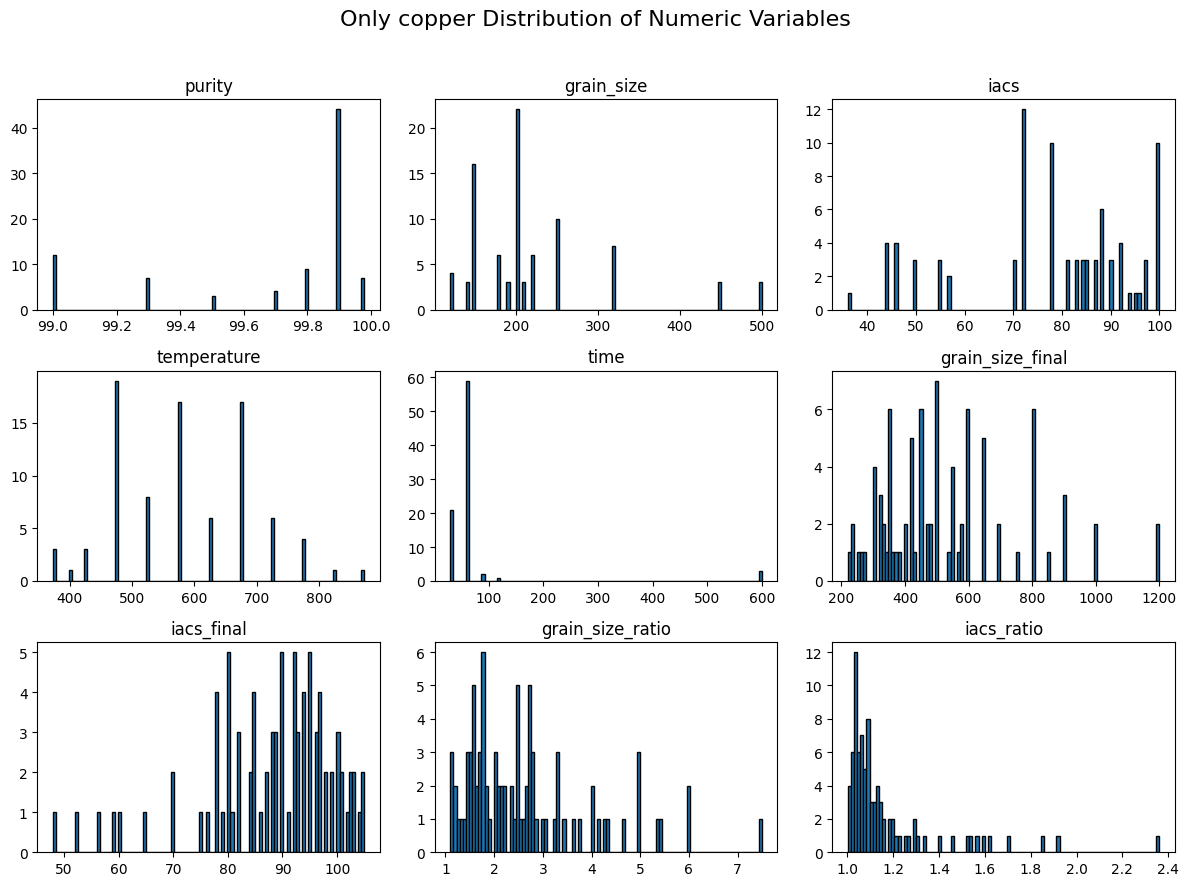

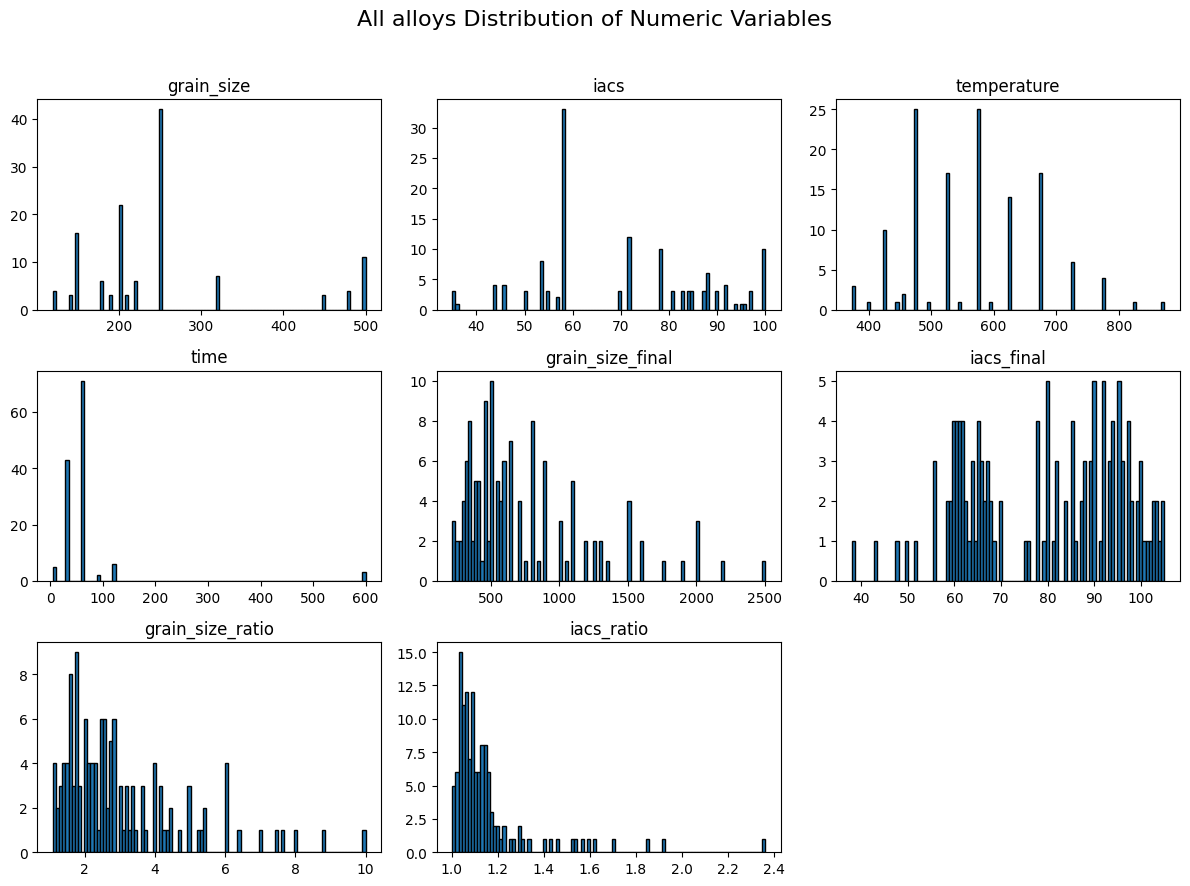

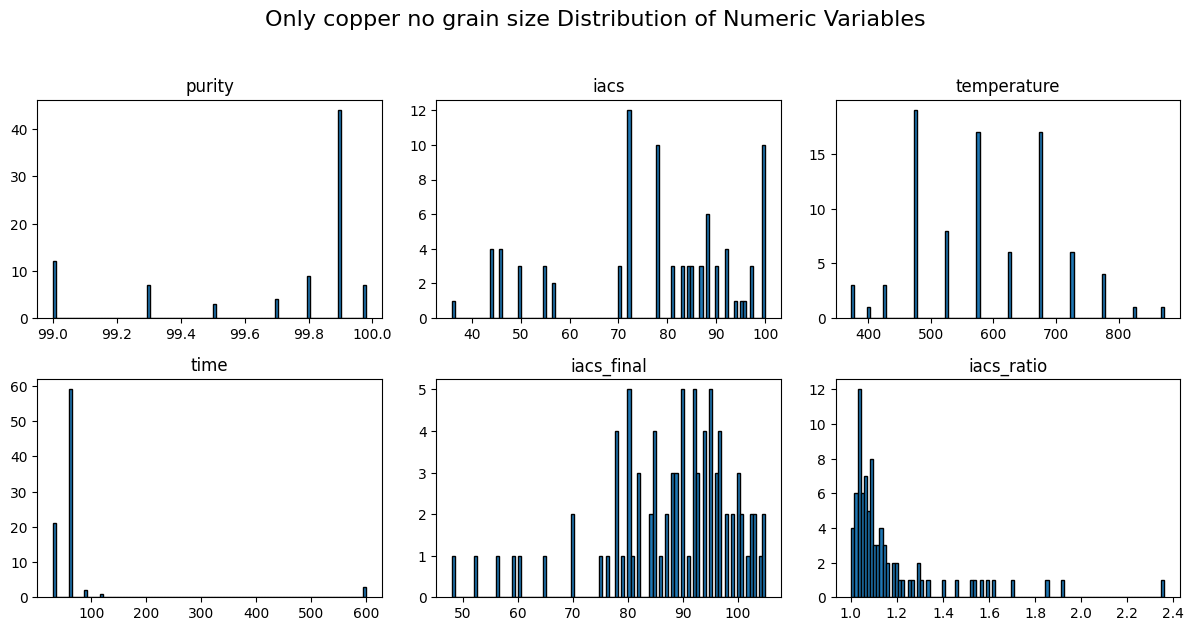

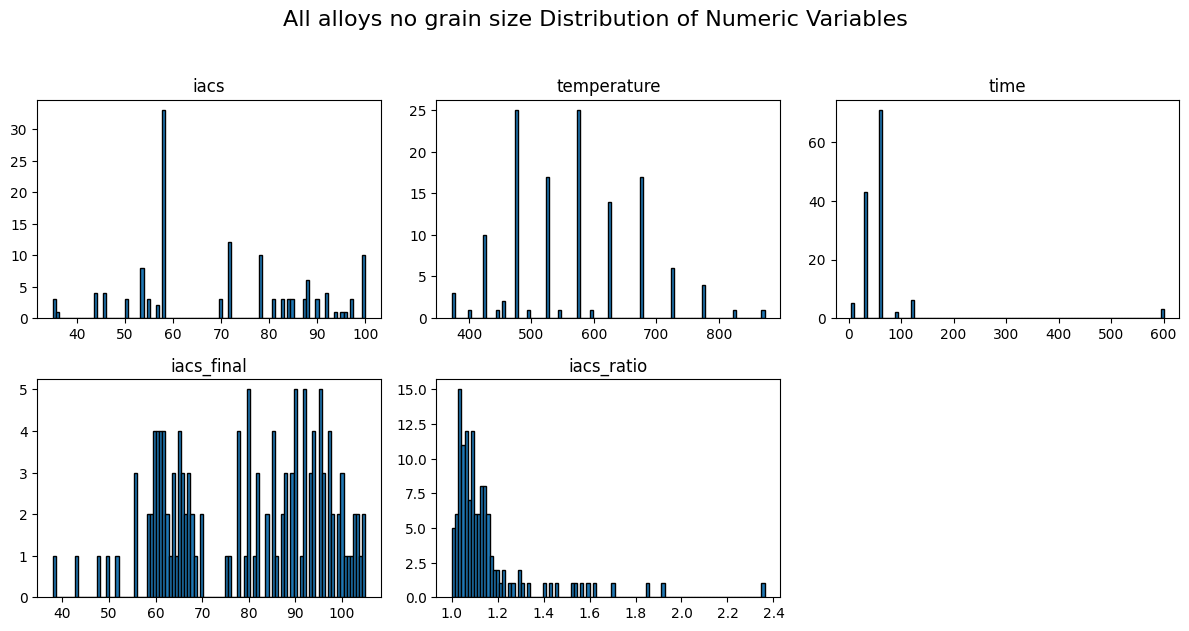

In [20]:
for key, df in df_edas.items():
    plot.plot_distributions(df, subplot_dim=(3, 3), bins=100, id=key)

## Correlation matrices

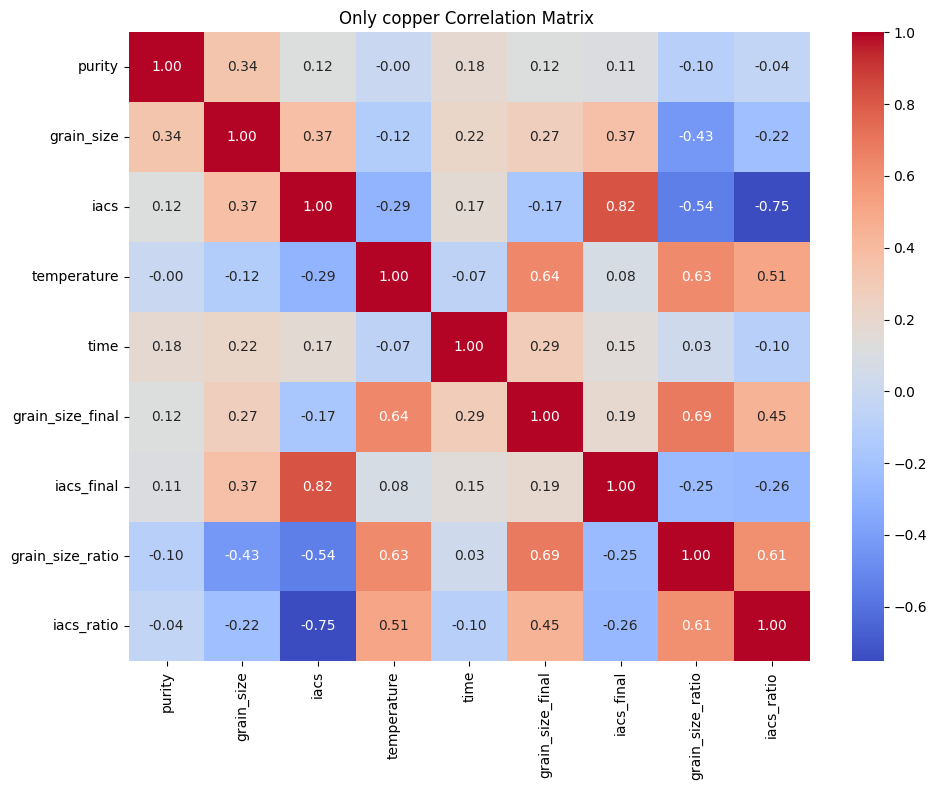

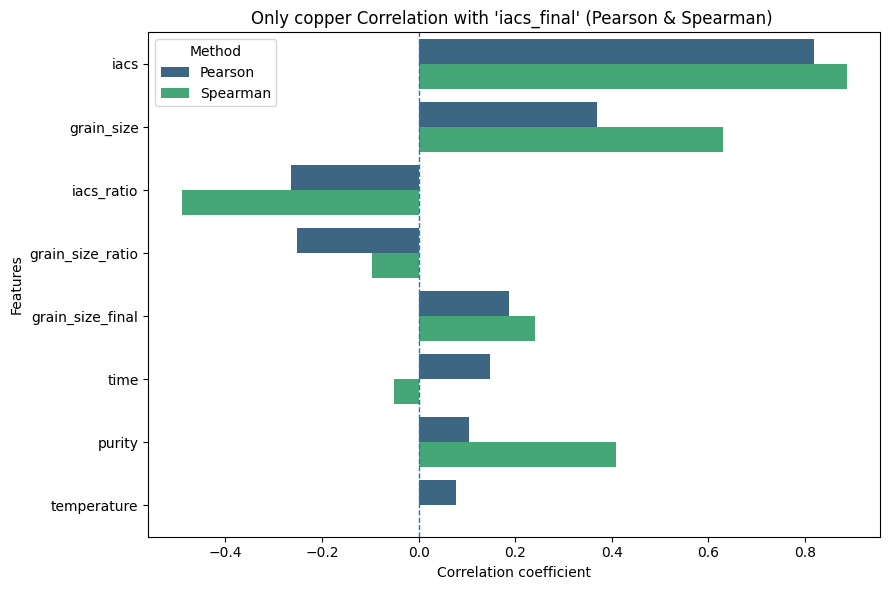

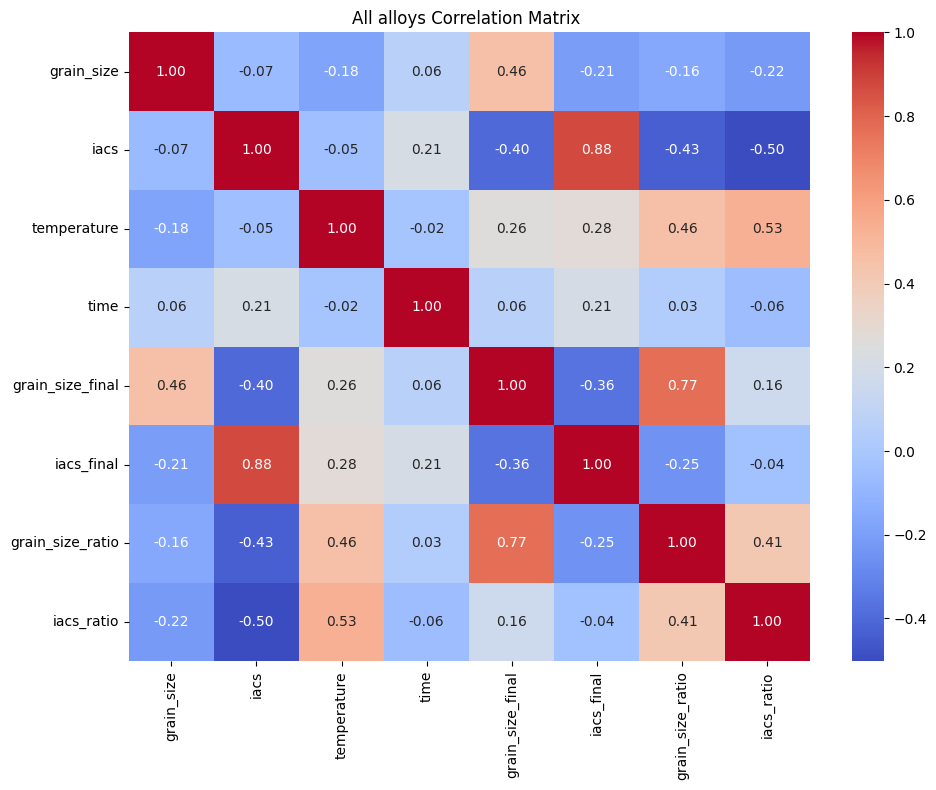

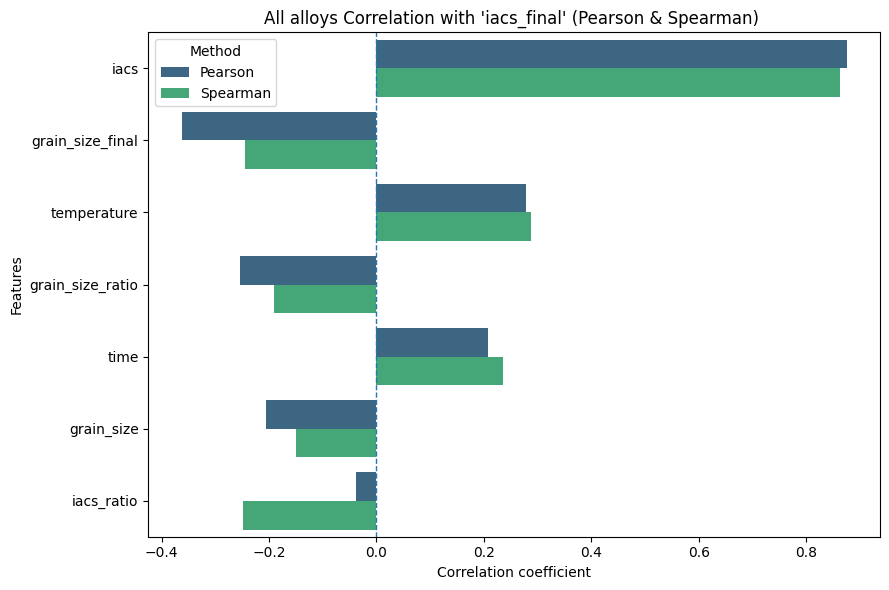

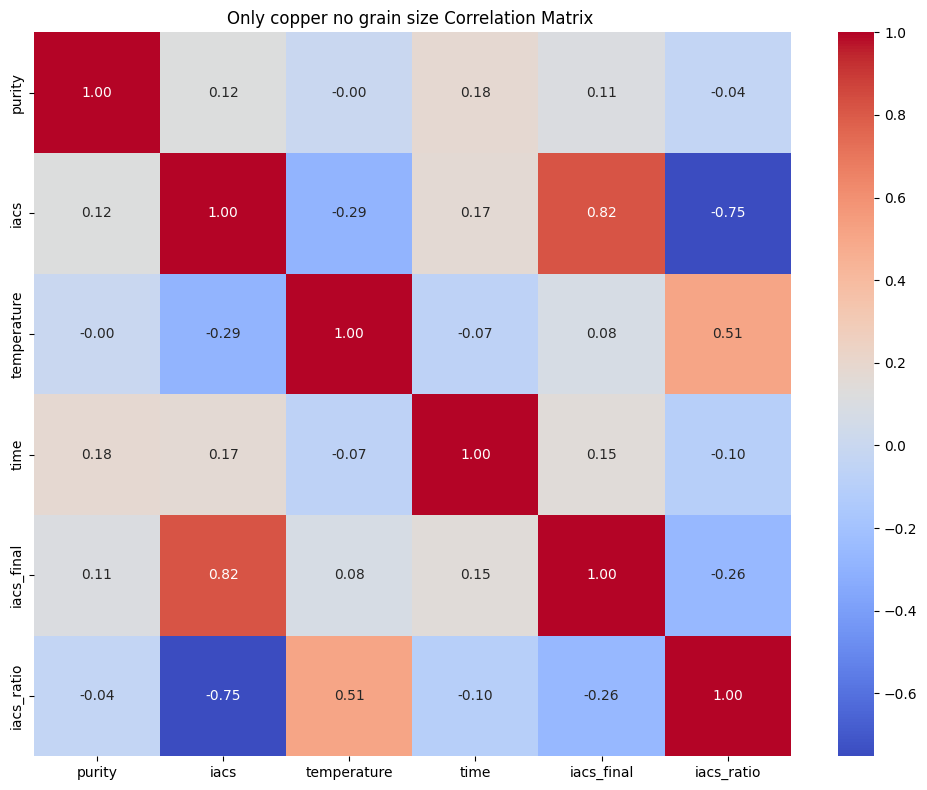

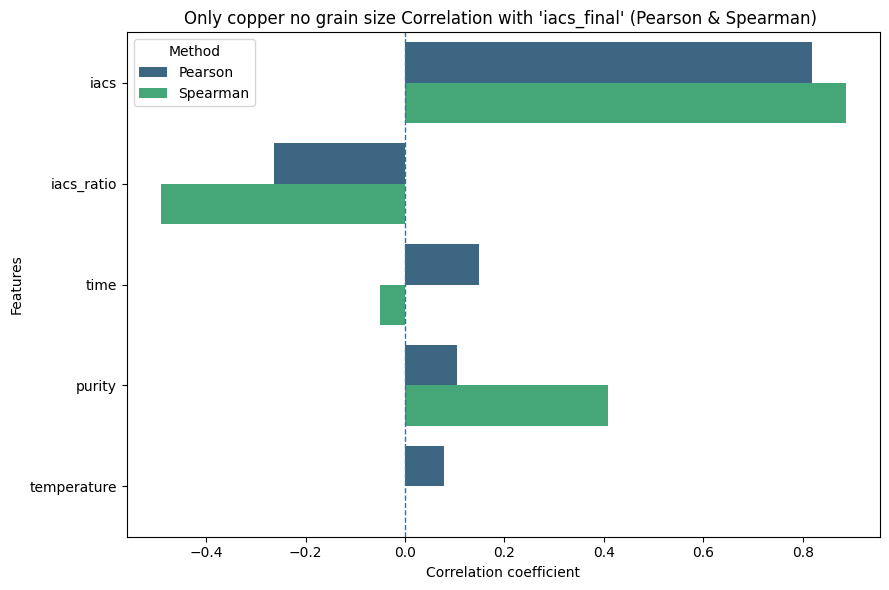

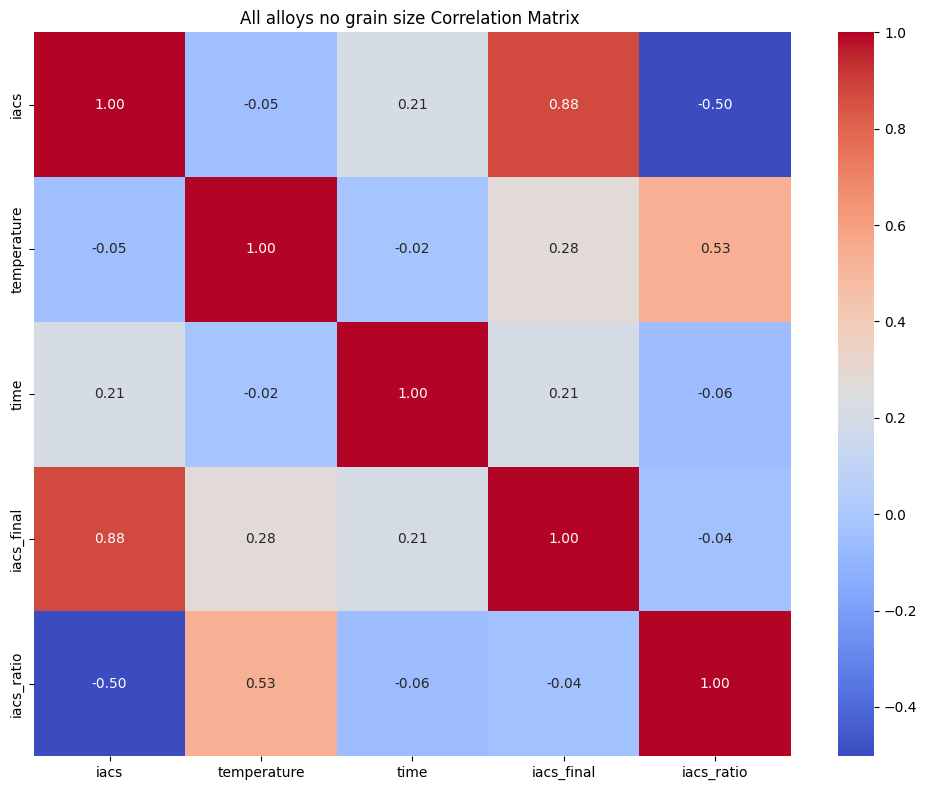

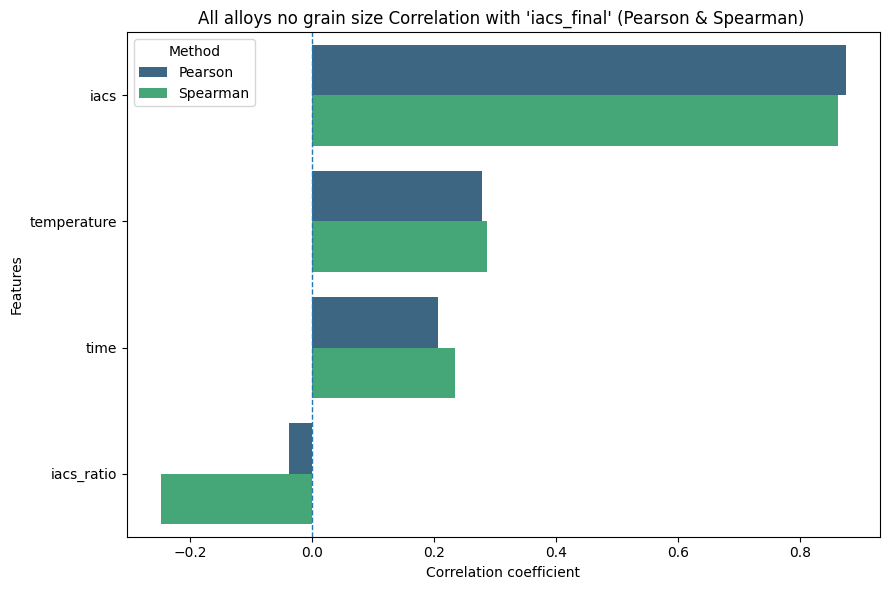

In [21]:
for k, df_k in df_edas.items():
    plot.plot_corr_matrix(df_k, id=k)
    plot.plot_target_correlations(df_k, target="iacs_final", id=k, top_n=20)


**Reduction of 44 lines cutting all alloys**

**Ideas:**
- With without purity (Cu alloys and all alloys)
-> Grain size 3 options: 
    - with grain size initial with grain size final 
    - with grain size initial wihout grain size final
    - without grain size initial without grain size final
- With without deep learning

**Total: 12 tries**

Ideas left aside or non applicable:

- Bootstrap
- Outliers
- Scalings



## Conclusions and observations:

- I was expecting that time had more impact on the annealing process. One explanation is that it might be "inverted" with the temperature, but still weird.

Conclusion above was taken away from the grain size EDA, but still lies here, except where all alloys are present. But on only copper alloys, temperature and time are almost neglected. 

# 